### Contents:
- [D4. Data Cleaning - Annotated Code](#d4)
- [E1. Principal Component Analysis (PCA)](#e1)
- [E2. Identify Principal Components](#e2)

<a id="d4"></a>
# D4. Annotated Code (Executable Script File)

Purpose: This codes cleans our dataset and mitigates data quality issues

In [1]:
# IMPORT PACKAGES

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### Read in the Data

In [3]:
# Read in the dataset, index_col indicates what column of the csv to use as the index of the dataframe 
df = pd.read_csv('medical_raw_data.csv', index_col=0)
df

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3191.048774,17939.403420,3,3,2,2,4,3,3,4
2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4214.905346,17612.998120,3,4,3,4,4,4,3,3
3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2177.586768,17505.192460,2,4,4,4,3,4,3,3
4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2465.118965,12993.437350,3,5,5,3,4,5,5,5
5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,1885.655137,3716.525786,2,1,3,3,5,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,9996,B863060,a25b594d-0328-486f-a9b9-0567eb0f9723,39184dc28cc038871912ccc4500049e5,Norlina,NC,Warren,27563,36.42886,-78.23716,...,6651.241294,8927.642189,3,2,2,3,4,3,4,2
9997,9997,P712040,70711574-f7b1-4a17-b15f-48c54564b70f,3cd124ccd43147404292e883bf9ec55c,Milmay,NJ,Atlantic,8340,39.43609,-74.87302,...,7851.522660,28507.147340,3,3,4,2,5,3,4,4
9998,9998,R778890,1d79569d-8e0f-4180-a207-d67ee4527d26,41b770aeee97a5b9e7f69c906a8119d7,Southside,TN,Montgomery,37171,36.36655,-87.29988,...,7725.953391,15281.214660,3,3,3,4,4,2,3,2
9999,9999,E344109,f5a68e69-2a60-409b-a92f-ac0847b27db0,2bb491ef5b1beb1fed758cc6885c167a,Quinn,SD,Pennington,57775,44.10354,-102.01593,...,8462.831883,7781.678412,5,5,3,4,4,3,4,3


In [4]:
# Get high-level overview of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 1 to 10000
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  Timezone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            7412 non-null   float64
 15  Age                 7586 non-null   float64
 16  Educ

### Remove Duplicates

In [5]:
# Remove any duplicate values
df = df.drop_duplicates()
df

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3191.048774,17939.403420,3,3,2,2,4,3,3,4
2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4214.905346,17612.998120,3,4,3,4,4,4,3,3
3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2177.586768,17505.192460,2,4,4,4,3,4,3,3
4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2465.118965,12993.437350,3,5,5,3,4,5,5,5
5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,1885.655137,3716.525786,2,1,3,3,5,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,9996,B863060,a25b594d-0328-486f-a9b9-0567eb0f9723,39184dc28cc038871912ccc4500049e5,Norlina,NC,Warren,27563,36.42886,-78.23716,...,6651.241294,8927.642189,3,2,2,3,4,3,4,2
9997,9997,P712040,70711574-f7b1-4a17-b15f-48c54564b70f,3cd124ccd43147404292e883bf9ec55c,Milmay,NJ,Atlantic,8340,39.43609,-74.87302,...,7851.522660,28507.147340,3,3,4,2,5,3,4,4
9998,9998,R778890,1d79569d-8e0f-4180-a207-d67ee4527d26,41b770aeee97a5b9e7f69c906a8119d7,Southside,TN,Montgomery,37171,36.36655,-87.29988,...,7725.953391,15281.214660,3,3,3,4,4,2,3,2
9999,9999,E344109,f5a68e69-2a60-409b-a92f-ac0847b27db0,2bb491ef5b1beb1fed758cc6885c167a,Quinn,SD,Pennington,57775,44.10354,-102.01593,...,8462.831883,7781.678412,5,5,3,4,4,3,4,3


### Update Data Types

Change the data types of the following columns with the astype() method for improved storage efficiency, ensure consistency and prevent future data analysis issues

In [6]:
# Cast columns with floating-point data types that contain simple "0/1" values to bool
# Fill missing values with blanks to warrant further investigation into missing values

df["Overweight"] = df["Overweight"].astype("bool")
df["Anxiety"] = df["Anxiety"].astype("bool")

In [7]:
# Cast columns with string (object) data types that contain simple "Yes/No" values to bool 

# Define mapping for our "Yes/No" values 
mapping = {'Yes': True, 'No': False}

# Apply mapping to relevant columns
df["ReAdmis"] = df["ReAdmis"].map(mapping)
df["Soft_drink"] = df["Soft_drink"].map(mapping)
df["HighBlood"] = df["HighBlood"].map(mapping)
df["Diabetes"] = df["Diabetes"].map(mapping)
df["Asthma"] = df["Asthma"].map(mapping)
df["Stroke"] = df["Stroke"].map(mapping)
df["Arthritis"] = df["Arthritis"].map(mapping)
df["Hyperlipidemia"] = df["Hyperlipidemia"].map(mapping)
df["BackPain"] = df["BackPain"].map(mapping)
df["Allergic_rhinitis"] = df["Allergic_rhinitis"].map(mapping)
df["Reflux_esophagitis"] = df["Reflux_esophagitis"].map(mapping)

# Convert Na values to blank strings in relevant columns while converting to boolean type
df["ReAdmis"] = df["ReAdmis"].fillna('').astype("bool")
df["Soft_drink"] = df["Soft_drink"].fillna('').astype("bool")
df["HighBlood"] = df["HighBlood"].fillna('').astype("bool")
df["Diabetes"] = df["Diabetes"].fillna('').astype("bool")
df["Asthma"] = df["Asthma"].fillna('').astype("bool")
df["Stroke"] = df["Stroke"].fillna('').astype("bool")
df["Arthritis"] = df["Arthritis"].fillna('').astype("bool")
df["Hyperlipidemia"] = df["Hyperlipidemia"].fillna('').astype("bool")
df["BackPain"] = df["BackPain"].fillna('').astype("bool")
df["Allergic_rhinitis"] = df["Allergic_rhinitis"].fillna('').astype("bool")
df["Reflux_esophagitis"] = df["Reflux_esophagitis"].fillna('').astype("bool")

In [8]:
# Cast columns with string (object) data types that represent predefined categories to category

# Area has 3 categories: Urban, Suburban, Rural
df["Area"] = df["Area"].astype("category")

# Timezone will have 7 categories: Eastern, Central, Mountain, Pacific, Alaska, Hawaii-Aleutian
df["Timezone"] = df["Timezone"].astype("category")

# Education has 12 categories: No Schooling Completed, Nursery School to 8th Grade, 9th Grade to 12th Grade (No Diploma), GED or Alternative Credential, Regular High School Diploma, Professional School Degree, Some College (Less than 1 Year), Some College (1 or More Years - No Degree), Associate's Degree, Bachelor's Degree, Master's Degree, Doctorate Degree
df["Education"] = df["Education"].astype("category")

# Employment has 5 categories: Umemployed, Full Time, Part Time, Retired, Student
df["Employment"] = df["Employment"].astype("category")

# Marital has 5 categories: Never Married, Married, Separated, Divorced, Widowed
df["Marital"] = df["Marital"].astype("category")

# Gender has 3 categories: Female, Male, Prefer not to answer (Nonbinary)
df["Gender"] = df["Gender"].astype("category")

# Inital_admin has 3 categories: Emergency, Elective, Observation
df["Initial_admin"] = df["Initial_admin"].astype("category")

# Complication_risk has 3 categories: Low, Medium, High
df["Complication_risk"] = df["Complication_risk"].astype("category")

# Services has 4 categories: Blood Work, Intravenous, CT Scan, MRI
df["Services"] = df["Services"].astype("category")

# The Item# columns each have up to 8 categories, given each represents a survey range from 1 to 8
df["Item1"] = df["Item1"].fillna(0).astype("category")
df["Item2"] = df["Item2"].fillna(0).astype("category")
df["Item3"] = df["Item3"].fillna(0).astype("category")
df["Item4"] = df["Item4"].fillna(0).astype("category")
df["Item5"] = df["Item5"].fillna(0).astype("category")
df["Item6"] = df["Item6"].fillna(0).astype("category")
df["Item7"] = df["Item7"].fillna(0).astype("category")
df["Item8"] = df["Item8"].fillna(0).astype("category")

In [9]:
# Cast the Zip column from int data type to string 

# Pad the string with zfill(5) to ensure each zip code is 5 characters long
df["Zip"] = df["Zip"].astype("str").str.zfill(5)

In [10]:
# Cast float columns to integers, filling NaN/Na values with 0 

# Children represents the number of children, so it should only contain whole numbers
df["Children"] = df["Children"].fillna(0).astype("int64")  

# Age represents age in years, which is more meaningful as a whole number
df["Age"] = df["Age"].fillna(0).astype("int64")  

# Initial_days represents days, which is more meaningful as a whole number
df["Initial_days"] = df["Initial_days"].fillna(0).astype("int64")  

In [11]:
# Check changes were implemented using info() method, checking the Dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 1 to 10000
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   CaseOrder           10000 non-null  int64   
 1   Customer_id         10000 non-null  object  
 2   Interaction         10000 non-null  object  
 3   UID                 10000 non-null  object  
 4   City                10000 non-null  object  
 5   State               10000 non-null  object  
 6   County              10000 non-null  object  
 7   Zip                 10000 non-null  object  
 8   Lat                 10000 non-null  float64 
 9   Lng                 10000 non-null  float64 
 10  Population          10000 non-null  int64   
 11  Area                10000 non-null  category
 12  Timezone            10000 non-null  category
 13  Job                 10000 non-null  object  
 14  Children            10000 non-null  int64   
 15  Age                 10000 non-null  

### Fix Missing Data

In [12]:
# Fill any remaining missing values   
df["Income"] = df["Income"].fillna(0) 
df = df.fillna('')

### Replace & Reformat Data

#### Reformat "Vitd_levels", "TotalCharge", and "Additional_charges" values
Use round() function to display float values with 2 decimal places instead of 8

In [13]:
# Previous values
df["VitD_levels"] 

1        17.802330
2        18.994640
3        17.415889
4        17.420079
5        16.870524
           ...    
9996     16.481612
9997     18.451601
9998     15.752751
9999     21.956305
10000    20.421883
Name: VitD_levels, Length: 10000, dtype: float64

In [14]:
# Reformat column to display float values with only 2 decimal places instead of 8
df["VitD_levels"] = df["VitD_levels"].round(2)

In [15]:
# Check changes were implemented
df["VitD_levels"] 

1        17.80
2        18.99
3        17.42
4        17.42
5        16.87
         ...  
9996     16.48
9997     18.45
9998     15.75
9999     21.96
10000    20.42
Name: VitD_levels, Length: 10000, dtype: float64

In [16]:
# Previous values
df["TotalCharge"] 

1        3191.048774
2        4214.905346
3        2177.586768
4        2465.118965
5        1885.655137
            ...     
9996     6651.241294
9997     7851.522660
9998     7725.953391
9999     8462.831883
10000    8700.856021
Name: TotalCharge, Length: 10000, dtype: float64

In [17]:
# Reformat column to display float values with only 2 decimal places instead of 8
df["TotalCharge"] = df["TotalCharge"].round(2)

In [18]:
# Check changes were implemented
df["TotalCharge"] 

1        3191.05
2        4214.91
3        2177.59
4        2465.12
5        1885.66
          ...   
9996     6651.24
9997     7851.52
9998     7725.95
9999     8462.83
10000    8700.86
Name: TotalCharge, Length: 10000, dtype: float64

In [19]:
# Previous values
df["Additional_charges"] 

1        17939.403420
2        17612.998120
3        17505.192460
4        12993.437350
5         3716.525786
             ...     
9996      8927.642189
9997     28507.147340
9998     15281.214660
9999      7781.678412
10000    11643.189930
Name: Additional_charges, Length: 10000, dtype: float64

In [20]:
# Reformat column to display float values with only 2 decimal places instead of 8
df["Additional_charges"] = df["Additional_charges"].round(2)

In [21]:
# Check changes were implemented
df["Additional_charges"] 

1        17939.40
2        17613.00
3        17505.19
4        12993.44
5         3716.53
           ...   
9996      8927.64
9997     28507.15
9998     15281.21
9999      7781.68
10000    11643.19
Name: Additional_charges, Length: 10000, dtype: float64

#### Replace "Timezone" values with standardized values

In [22]:
# Previous values
df.Timezone.value_counts()

America/New_York                  3889
America/Chicago                   3771
America/Los_Angeles                937
America/Denver                     612
America/Detroit                    262
America/Indiana/Indianapolis       151
America/Phoenix                    100
America/Boise                       86
America/Anchorage                   50
America/Puerto_Rico                 43
Pacific/Honolulu                    34
America/Menominee                   14
America/Nome                        12
America/Indiana/Vincennes            8
America/Sitka                        6
America/Kentucky/Louisville          6
America/Toronto                      5
America/Indiana/Tell_City            3
America/Indiana/Marengo              3
America/North_Dakota/Beulah          2
America/Indiana/Winamac              1
America/Indiana/Vevay                1
America/North_Dakota/New_Salem       1
America/Indiana/Knox                 1
America/Yakutat                      1
America/Adak             

In [23]:
# Define a dictionary mapping timezones to standardized values - this makes it easier to update/modify 
standaridized_timezones = {
    # Atlantic Standard Time
    "America/Puerto_Rico": "Atlantic Standard Time (GMT-4)",
    # Eastern Standard Time
    "America/New_York": "Eastern Standard Time (GMT-5)",
    "America/Detroit": "Eastern Standard Time (GMT-5)",
    "America/Indiana/Indianapolis": "Eastern Standard Time (GMT-5)",
    "America/Indiana/Vevay": "Eastern Standard Time (GMT-5)",
    "America/Indiana/Vincennes": "Eastern Standard Time (GMT-5)",
    "America/Kentucky/Louisville": "Eastern Standard Time (GMT-5)",
    "America/Toronto": "Eastern Standard Time (GMT-5)",
    "America/Indiana/Marengo": "Eastern Standard Time (GMT-5)",
    "America/Indiana/Winamac": "Eastern Standard Time (GMT-5)",
    # Central Standard Time
    "America/Chicago": "Central Standard Time (GMT-6)", 
    "America/Menominee": "Central Standard Time (GMT-6)",
    "America/Indiana/Knox": "Central Standard Time (GMT-6)",
    "America/Indiana/Tell_City": "Central Standard Time (GMT-6)",
    "America/North_Dakota/Beulah": "Central Standard Time (GMT-6)",
    "America/North_Dakota/New_Salem": "Central Standard Time (GMT-6)",
    # Mountain Standard Time
    "America/Denver": "Mountain Standard Time (GMT-7)",
    "America/Boise": "Mountain Standard Time (GMT-7)",
    "America/Phoenix": "Mountain Standard Time (GMT-7)",
    # Pacific Standard Time
    "America/Los_Angeles": "Pacific Standard Time (GMT-8)",
    # Alaska Standard Time
    "America/Nome": "Alaska Standard Time (GMT-9)",
    "America/Anchorage": "Alaska Standard Time (GMT-9)",
    "America/Sitka": "Alaska Standard Time (GMT-9)",
    "America/Yakutat": "Alaska Standard Time (GMT-9)",
    # Hawaii-Aleutian Standard Time
    "America/Adak": "Hawaii-Aleutian Standard Time (GMT-10)",
    "Pacific/Honolulu": "Hawaii-Aleutian Standard Time (GMT-10)" 
}

# Replace Timezones using the dictionary
df["Timezone"].replace(standaridized_timezones, inplace=True)

In [24]:
# Check changes were implemented
df.Timezone.value_counts()

Eastern Standard Time (GMT-5)             4326
Central Standard Time (GMT-6)             3792
Pacific Standard Time (GMT-8)              937
Mountain Standard Time (GMT-7)             798
Alaska Standard Time (GMT-9)                69
Atlantic Standard Time (GMT-4)              43
Hawaii-Aleutian Standard Time (GMT-10)      35
Name: Timezone, dtype: int64

#### Replace "Gender" values 

In [25]:
# Previous values
df.Gender.value_counts()

Female                  5018
Male                    4768
Prefer not to answer     214
Name: Gender, dtype: int64

In [26]:
# Define a dictionary mapping genders - this makes it easier to update/modify if hospital chooses to add more gender options in the future
standaridized_genders = {
    "Female": "Female",
    "Male": "Male",
    "Prefer not to answer": "Non-Binary"
}

# Replace Genders using the dictionary
df["Gender"].replace(standaridized_genders, inplace=True)

In [27]:
# Check changes were implemented
df.Gender.value_counts()

Female        5018
Male          4768
Non-Binary     214
Name: Gender, dtype: int64

#### Replace "Item#" values

In [28]:
# Previous values - example for Item1 
df.Item8.value_counts()

3    3401
4    3337
5    1429
2    1391
6     221
1     209
7      12
Name: Item8, dtype: int64

In [29]:
# Define a dictionary mapping survey responses to their equivocal meanings
standaridized_survey_responses = {
    0: "4: Neutral", # Make NaN/0 values Neutral
    1: "1: Most Important",
    2: "2: Very Important",
    3: "3: Somewhat Important",
    4: "4: Neutral",
    5: "5: Slightly Unimportant",
    6: "6: Unimportant",
    7: "7: Very Unimportant",
    8: "8: Least Uimportant"
}

# Replace survey response values using the dictionary
df["Item1"].replace(standaridized_survey_responses, inplace=True)
df["Item2"].replace(standaridized_survey_responses, inplace=True)
df["Item3"].replace(standaridized_survey_responses, inplace=True)
df["Item4"].replace(standaridized_survey_responses, inplace=True)
df["Item5"].replace(standaridized_survey_responses, inplace=True)
df["Item6"].replace(standaridized_survey_responses, inplace=True)
df["Item7"].replace(standaridized_survey_responses, inplace=True)
df["Item8"].replace(standaridized_survey_responses, inplace=True)

In [30]:
# Check changes were implemented
df.Item8.value_counts()

3: Somewhat Important      3401
4: Neutral                 3337
5: Slightly Unimportant    1429
2: Very Important          1391
6: Unimportant              221
1: Most Important           209
7: Very Unimportant          12
Name: Item8, dtype: int64

### Relabel Columns

In [31]:
# Define updated column labels, standardized and more accurate to the data they reflect
updated_labels = ["case_order", "customer_id", "interaction_id", "uid", "city", "region", "county", 
                    "zip_code", "latitude_gps_coordinate", "longitude_gps_coordinate", "population", "area_type", "time_zone", "policyholder_job", "children_in_household", 
                    "age", "education", "employment_status", "policyholder_income", "policyholder_marital_status", "gender_identity", "is_readmission", 
                    "vitamin_d_level", "physician_visits", "full_meals_consumed", "vitamin_d_supplements", "habitual_soda_consumption", "initial_admission_type", 
                    "high_blood_pressure", "stroke", "complication_risk_level", "overweight", "arthritis", "diabetes", "hyperlipidemia", 
                    "back_pain", "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma", "services_provided", 
                    "inital_days_hospitalized", "avg_daily_charges", "avg_additional_charges", "survey_question1_timely_admission", "survey_question2_timely_treatment", 
                    "survey_question3_timely_visits", "survey_question4_reliability", "survey_question5_options", "survey_question6_hours_of_treatment", "survey_question7_courteous_staff", 
                    "survey_question8_physician_actively_listens"]

# Assign updated column labels
df.columns = updated_labels

In [32]:
# Check changes were implemented
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head(100)

,case_order,customer_id,interaction_id,uid,city,region,county,zip_code,latitude_gps_coordinate,longitude_gps_coordinate,population,area_type,time_zone,policyholder_job,children_in_household,age,education,employment_status,policyholder_income,policyholder_marital_status,gender_identity,is_readmission,vitamin_d_level,physician_visits,full_meals_consumed,vitamin_d_supplements,habitual_soda_consumption,initial_admission_type,high_blood_pressure,stroke,complication_risk_level,overweight,arthritis,diabetes,hyperlipidemia,back_pain,anxiety,allergic_rhinitis,reflux_esophagitis,asthma,services_provided,inital_days_hospitalized,avg_daily_charges,avg_additional_charges,survey_question1_timely_admission,survey_question2_timely_treatment,survey_question3_timely_visits,survey_question4_reliability,survey_question5_options,survey_question6_hours_of_treatment,survey_question7_courteous_staff,survey_question8_physician_actively_listens
1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,Central Standard Time (GMT-6),"Psychologist, sport and exercise",1,53,"Some College, Less than 1 Year",Full Time,86575.93,Divorced,Male,False,17.80,6,0,0,False,Emergency Admission,True,False,Medium,False,True,True,False,True,True,True,False,True,Blood Work,10,3191.05,17939.40,3: Somewhat Important,3: Somewhat Important,2: Very Important,2: Very Important,4: Neutral,3: Somewhat Important,3: Somewhat Important,4: Neutral
2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,Central Standard Time (GMT-6),Community development worker,3,51,"Some College, 1 or More Years, No Degree",Full Time,46805.99,Married,Female,False,18.99,4,2,1,False,Emergency Admission,True,False,High,True,False,False,False,False,True,False,True,False,Intravenous,15,4214.91,17613.00,3: Somewhat Important,4: Neutral,3: Somewhat Important,4: Neutral,4: Neutral,4: Neutral,3: Somewhat Important,3: Somewhat Important
3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,Central Standard Time (GMT-6),Chief Executive Officer,3,53,"Some College, 1 or More Years, No Degree",Retired,14370.14,Widowed,Female,False,17.42,4,1,0,False,Elective Admission,True,False,Medium,True,False,True,False,False,True,False,False,False,Blood Work,4,2177.59,17505.19,2: Very Important,4: Neutral,4: Neutral,4: Neutral,3: Somewhat Important,4: Neutral,3: Somewhat Important,3: Somewhat Important
4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,Central Standard Time (GMT-6),Early years teacher,0,78,GED or Alternative Credential,Retired,39741.49,Married,Male,False,17.42,4,1,0,False,Elective Admission,False,True,Medium,False,True,False,False,False,True,False,True,True,Blood Work,1,2465.12,12993.44,3: Somewhat Important,5: Slightly Unimportant,5: Slightly Unimportant,3: Somewhat Important,4: Neutral,5: Slightly Unimportant,5: Slightly Unimportant,5: Slightly Unimportant
5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,Eastern Standard Time (GMT-5),Health promotion specialist,0,22,Regular High School Diploma,Full Time,1209.56,Widowed,Female,False,16.87,5,0,2,True,Elective Admission,False,False,Low,False,False,False,True,False,False,True,False,False,CT Scan,1,1885.66,3716.53,2: Very Important,1: Most Important,3: Somewhat Important,3: Somewhat Important,5: Slightly Unimportant,3: Somewhat Important,4: Neutral,3: Somewhat Important
6,6,S543885,e3b0a319-9e2e-4a23-8752-2fdc736c30f4,03e447146d4a32e1aaf75727c3d1230c,Braggs,OK,Muskogee,74423,35.67302,-95.19180,981,Urban,Central Standard Time (GMT-6),Corporate treasurer,0,76,Regular High School Diploma,Retired,0.00,Never Married,Male,False,19.96,6

In [33]:
# Export cleaned data to CSV 
df.to_csv('medical_clean_data.csv')

<a id="e1"></a>
# E1. Principal Component Analysis (PCA)
Purpose: Identify the total number of principal components and provide the output of the principal components loading matrix

In [34]:
# STORE QUANTITATIVE VARIABLES

# Create a dedicated data frame containing only our quantitative variables for PCA (principal component analysis)
df_pca = df[["latitude_gps_coordinate", "longitude_gps_coordinate", "population", "children_in_household", "age", "policyholder_income", "vitamin_d_level", "physician_visits", "full_meals_consumed", "vitamin_d_supplements", "inital_days_hospitalized", "avg_daily_charges", "avg_additional_charges"]]

# NORMALIZE DATA

# Standaridze each variable by subtracting the mean and dividing by the std (standard deviation)
df_normalized_pca = (df_pca - df_pca.mean()) / df_pca.std()

# SET PCA SIZE

# Specify the number of principal components (PCs) to retain
pca = PCA(n_components=df_pca.shape[1])

In [35]:
# FIT THE MODEL

# Fit the normalized data to the PCA model, capturing most important directions of variance in the data
pca.fit(df_normalized_pca)

PCA(n_components=13)

In [36]:
# CREATE PRINTABLE PCA DATA

# Create a data frame containing the transformed data projected onto the principal components 
printable_pca = pd.DataFrame(pca.transform(df_normalized_pca), columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "PC11", "PC12", "PC13"])

# GENERATE LOADINGS

# Create a data frame showing the loadings for each PC
# Each loading represents the correlation between a variable and a PC, indicating how much each feature contributes to that PC
pca_loadings = pd.DataFrame(pca.components_.T, columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "PC11", "PC12", "PC13"], index=df_normalized_pca.columns)

# PRINT LOADINGS

# Print the data frame to examine the correlations and interpret the meaning of each PC
pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
latitude_gps_coordinate,-0.019040,0.023955,-0.715140,0.117357,-0.060860,0.003342,-0.041279,-0.061812,-0.045629,-0.032326,0.679135,0.016400,0.002365
longitude_gps_coordinate,-0.004369,0.028830,0.273628,-0.592108,-0.372867,0.340515,0.377267,0.090325,-0.090028,0.108452,0.383671,0.033852,0.000529
population,0.024136,-0.056457,0.629736,0.288576,0.225043,-0.161601,-0.225558,-0.068005,0.035257,-0.030678,0.617999,-0.004212,-0.000620
children_in_household,-0.001480,0.008555,0.015820,0.241122,0.200363,-0.238385,0.792937,-0.399989,-0.191821,0.135710,-0.000267,-0.024660,0.000496
age,0.027347,0.703845,0.033119,0.008760,-0.043299,-0.031647,-0.028121,0.004472,-0.024380,-0.040154,0.017715,-0.704576,0.006824
policyholder_income,-0.002999,0.015667,0.020498,0.382457,0.131638,0.401748,0.358316,0.555339,0.107582,-0.474793,0.021429,0.008224,0.000788
vitamin_d_level,0.562169,-0.001437,-0.044499,-0.193577,0.294934,0.236292,-0.008809,-0.306174,0.228786,-0.193534,0.007792,-0.016595,-0.563682
physician_visits,-0.007408,0.003876,0.012389,0.223005,0.198445,0.634883,-0.188456,-0.120668,-0.571329,0.356800,-0.054313,-0.028954,-0.000792
full_meals_consumed,-0.007822,0.036794,-0.101559,-0.225136,0.583100,-0.085281,0.086984,0.454708,0.237512,0.558935,0.073346,-0.041888,0.005185
vitamin_d_supplements,0.032285,-0.001060,0.029638,0.393395,-0.375709,0.276738,0.054142,-0.155063,0.629205,0.448624,-0.017236,-0.033783,-0.000325


Principal components: PC1, PC2, PC3, PC4, PC5, PC6

<a id="e2"></a>
# E2. Identify Principal Components
Purpose: Justify reduced number of principal components

In [37]:
# Calculate the covariance matrix of the normalized data after PCA
covariance_matrix = np.dot(df_normalized_pca.T, df_normalized_pca) / df_pca.shape[0]

# Compute the eigenvalues of the covariance using the eigenvectors obtained from the PCA
eigenvalues = [np.dot(eigenvector.T, np.dot(covariance_matrix, eigenvector)) for eigenvector in pca.components_]
# Each eigenvalue is calculated as the dot product of an eigenvector with the product of the covariance matrix and the same eigenvector

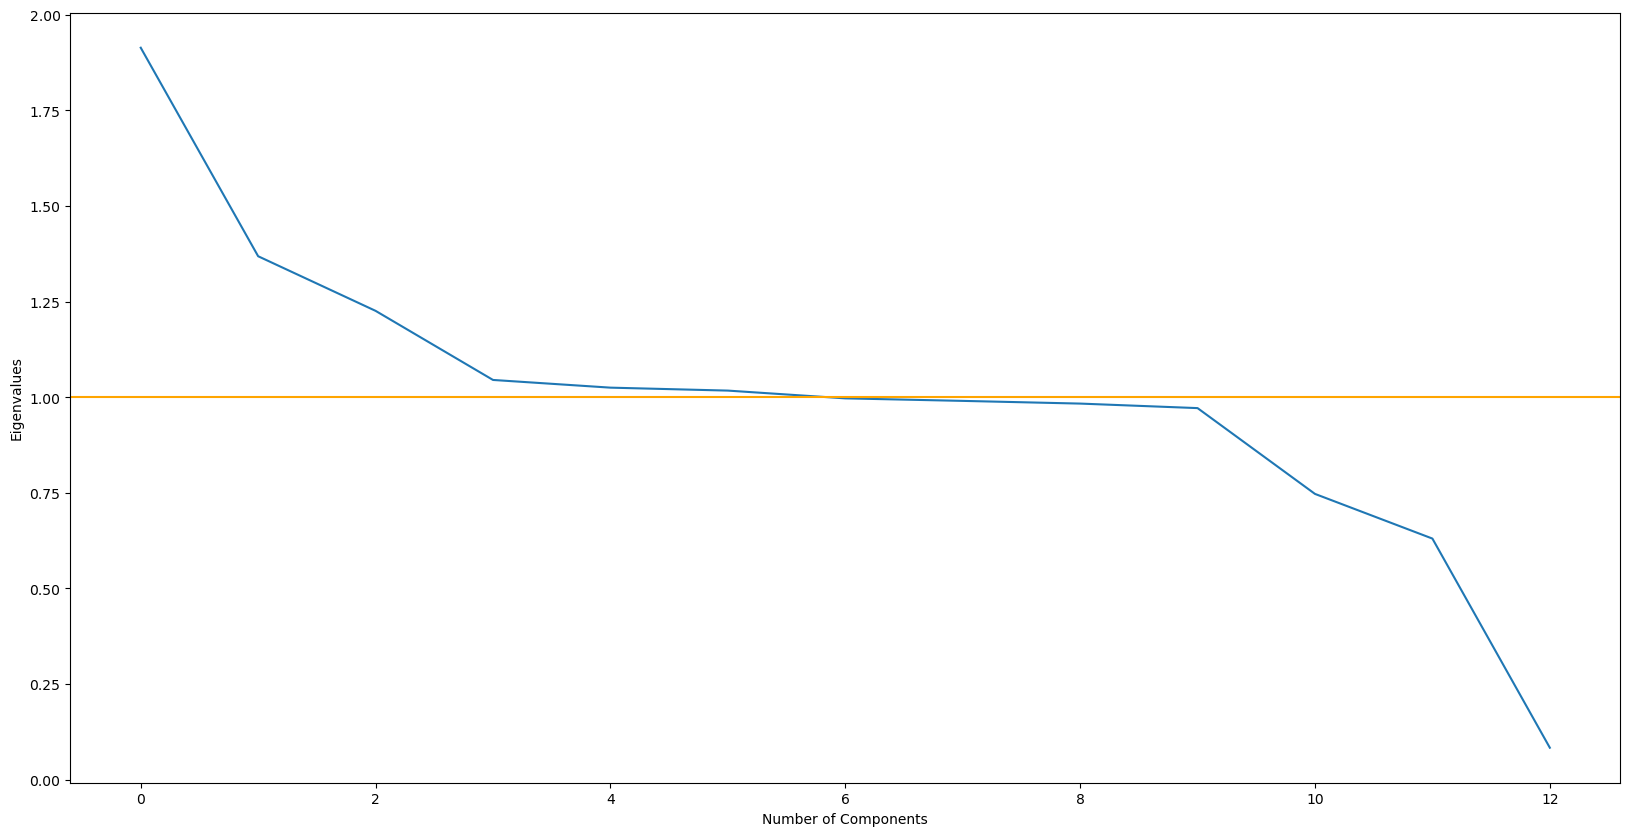

In [38]:
# Generate Scree Plot
plt.figure(figsize = [20,10]) 
plt.plot(eigenvalues)
plt.xlabel('Number of Components')
plt.ylabel('Eigenvalues')
plt.axhline(y=1, color='orange')
plt.show()

In [39]:
# Print array of eigenvalues
eigenvalues

[1.9136268444029696,
 1.3684900837103073,
 1.22574526908525,
 1.045100058263724,
 1.0249832616301577,
 1.0172706643103397,
 0.9969944209674451,
 0.9903851136834361,
 0.9833121363165764,
 0.9714989569432093,
 0.7471998134173358,
 0.6304251196221257,
 0.08366825764688132]